In [1]:
from mpasdiag import MPAS2DProcessor, MPASConfig, GeographicBounds, PrecipitationDiagnostics
from mpasdiag import (
    MPASPrecipitationPlotter, PrecipitationRenderStyle,
)

In [2]:
proc = MPAS2DProcessor(grid_file="../data/grids/x1.10242.static.nc")
proc.load_2d_data("../data/u240k/diag")

In [3]:
# Diagnostic: 1-hour accumulation ending at time index 1
tindex = 1
diag = PrecipitationDiagnostics(verbose=True)
precip = diag.compute_precipitation_difference(
    proc.dataset, tindex, var_name="total", accum_period="a01h",
    data_type=proc.data_type or "xarray",
)
lon, lat = proc.extract_2d_coordinates_for_variable("total", precip)

In [4]:
cfg = MPASConfig()
cfg.time_index = tindex                      # ensures the period annotation tracks the step
cfg.remap_engine, cfg.remap_method = "kdtree", "nearest"
bounds = GeographicBounds(-180, 180, -90, 90)

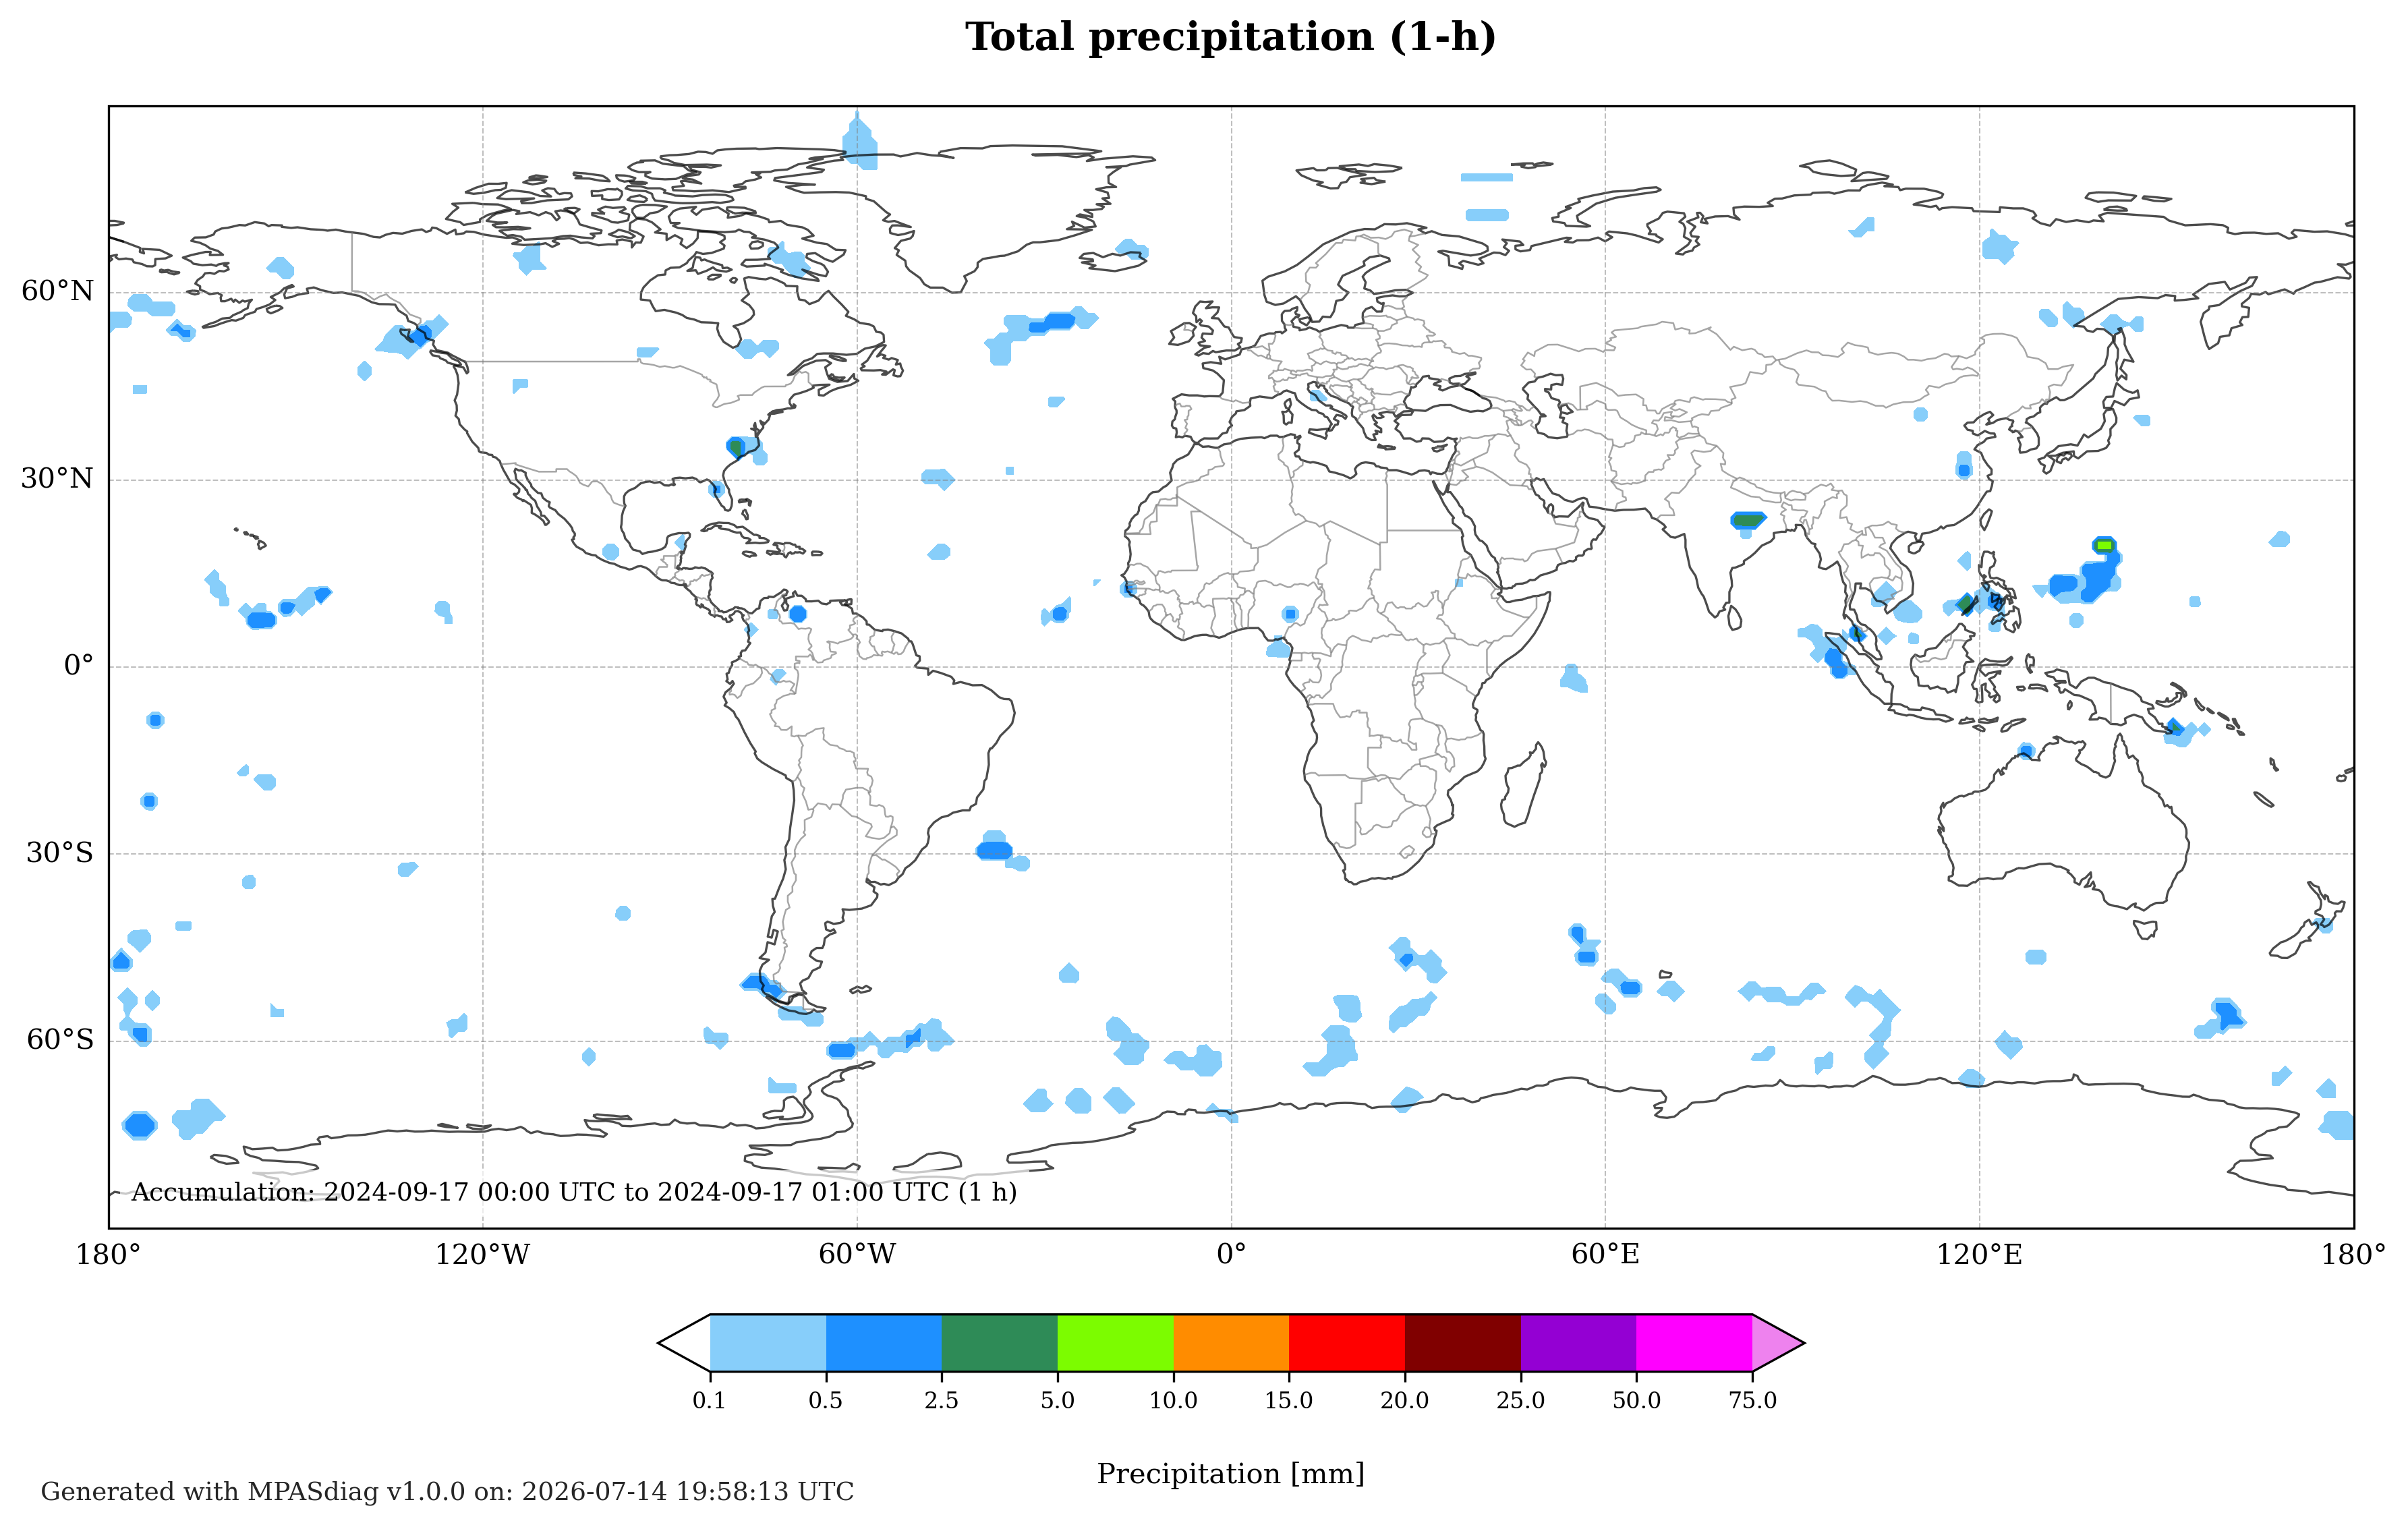

In [5]:
plotter = MPASPrecipitationPlotter(figsize=(12, 8), dpi=300)
fig, ax = plotter.create_precipitation_map(
    lon, lat, precip.values, bounds,
    accum_period="a01h",
    data_array=precip, dataset=proc.dataset, config=cfg,
    style=PrecipitationRenderStyle(title="Total precipitation (1-h)",
                                   plot_type="contourf", grid_resolution=1.0),
)

In [6]:
plotter.save_plot("./output/total_precip_a01h", formats=["png"])
plotter.close_plot()